# DATA-445: Homework Assignment 4

**Instructions**

- This homework assignment is worth **119** points.
- Please submit a **.ipynb** file to Blackboard.
- **Please strive for clarity and organization.**
- **AI usage**:
  - AI use is strictly **prohibited** for conceptual exercises.
  - For applied (Python) exercises, you may use AI exclusively for **debugging**. Do not use AI to generate answers.
- **Due Date: October 2, 2026, by 11:59 PM.**

## Exercise 1

(5 points) What is a perceptron? Be specific.

A perceptron basically is used for classification, it calculates a weighted sum of its inputs and uses a threshold function to seperate the data into two categories.  

## Exercise 2

(5 points) What are the different types of perceptrons? Briefly describe each of them.

There is a single perceptron and a multilayer perceptron (MLP). The MLP solves non linear problems and by having multiple layers the network can model non linear boundaries between classes otherwise impossible with single perceptron. The single perceptron only performs on linear patterns and has no hidden layers.

## Exercise 3

(5 points) What is a hard margin in a support vector machine model? Be specific.

This is a rule that forces data to be seperable without errors. If there is a lot of noise in the model it will fail because it does not allow misclassifications and it can become overfit very easily.

## Exercise 4

(4 points) The effectiveness of a support vector machine model depends on:

(a) kernel  
(b) kernel parameters  
(c) penalty cost parameter  
(d) All of the above  
(e) None of the above

(d)

## Exercise 5

(4 points) What is/are **true** about kernel in SVM?

(a) Kernel function map low dimensional data into high dimensional space.  
(b) Kernel function map high dimensional data into low dimensional space.  
(c) It is a similarity function.  
(d) (a) and (c)  
(e) (b) and (c)  
(f) (a), (b) and (c)  
(g) None of the above

(d)

## Exercise 6

(4 points) Which of the following statements is **true** regarding the role of the activation function in the hidden layer(s) of a multi-layer perceptron (MLP)?

(a) It has no effect on the model's ability to learn non-linear patterns.  
(b) It allows the network to learn and approximate non-linear decision boundaries.  
(c) It is only necessary in the output layer, not in the hidden layer(s).  
(d) It converts the MLP into a linear model, regardless of the number of hidden layers.  
(e) None of the above.

(b)

## Exercise 7

(5 points) What is a **soft margin** in a support vector machine model? How does the penalty (cost) parameter $C$ affect the trade-off between the width of the margin and the number of misclassified observations? Be specific.

The soft margin lets some data points cross the margin boundary to have a better overall seperation when the data is not perfectly seperable. With a high cost parameter this makes a small margin with less misclassifications and on the other hand a low cost parameter allows for more training errors. 

## Exercise 8

Consider the `framingham.csv` data file. The dataset is publically available on the Kaggle website, and it is from an ongoing cardiovascular study on residents of the town of Framingham, Massachusetts. The classification goal is to predict whether the patient has 10-year risk of future coronary heart disease (CHD). The dataset provides the patients' information. It includes over 4,000 records and 15 attributes. Each attribute is a potential risk factor. There are both demographic, behavioral and medical risk factors.

- **Demographic**:
  - Sex: male or female (Nominal)
  - Age: Age of the patient (Continuous - Although the recorded ages have been truncated to whole numbers, the concept of age is continuous)

- **Behavioral**
  - Current Smoker: whether or not the patient is a current smoker (Nominal)
  - Cigs Per Day: the number of cigarettes that the person smoked on average in one day (can be considered continuous as one can have any number of cigarettes, even half a cigarette)

- **Medical (history)**
  - BP Meds: whether or not the patient was on blood pressure medication (Nominal)
  - Prevalent Stroke: whether or not the patient had previously had a stroke (Nominal)
  - Prevalent Hyp: whether or not the patient was hypertensive (Nominal)
  - Diabetes: whether or not the patient had diabetes (Nominal)

- **Medical (current)**
  - Tot Chol: total cholesterol level (Continuous)
  - Sys BP: systolic blood pressure (Continuous)
  - Dia BP: diastolic blood pressure (Continuous)
  - BMI: Body Mass Index (Continuous)
  - Heart Rate: heart rate (Continuous - In medical research, variables such as heart rate though in fact discrete, yet are considered continuous because of large number of possible values.)
  - Glucose: glucose level (Continuous)

- **Predict variable (desired target)**
  - 10 year risk of coronary heart disease CHD (binary: "1", means "Yes", "0" means "No")

**In Python**, answer the following:

### (a)

(4 points) Using the `pandas` library, read the csv data file and create a data-frame called `heart`.

In [26]:
import pandas as pd

heart = pd.read_csv('framingham.csv')

heart.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


### (b)

(3 points) Remove observations with missing values.

In [27]:
heart = heart.dropna()

heart.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


### (c)

(60 points) Using `age`, `currentSmoker`, `totChol`, `BMI`, and `heartRate` as the predictor variables, and `TenYearCHD` as the target variable, do the following:

#### (i)

Set up a 5-fold cross-validation splitter (e.g., `StratifiedKFold` with `n_splits = 5`) on the predictor and target variables, and generate the `train`/`validation` indices for each of the 5 folds.

In [28]:
from sklearn.model_selection import StratifiedKFold

X = heart[['age', 'currentSmoker', 'totChol', 'BMI', 'heartRate']]
y = heart['TenYearCHD']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#### (ii)

Using `MinMaxScaler`, transform the input variables of each fold's `train` and `validation` sets to 0-1 scale. This scaling must be applied independently within each fold, before building any of the models below.

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import recall_score

md = make_pipeline(MinMaxScaler(),
                   LogisticRegression(random_state=42))

recall_scores = []
for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    md.fit(X_train, y_train)
    md_pred = md.predict_proba(X_test)[:, 1]
    md_pred_label = (md_pred >= 0.15).astype(int)
    
    score = recall_score(y_test, md_pred_label)
    recall_scores.append(score)
    print(f"Fold {i+1} Recall Score: {score:.4f}")
    
print(f"Average Recall Score: {sum(recall_scores)/len(recall_scores):.4f}")

Fold 1 Recall Score: 0.5625
Fold 2 Recall Score: 0.6306
Fold 3 Recall Score: 0.7748
Fold 4 Recall Score: 0.7297
Fold 5 Recall Score: 0.6518
Average Recall Score: 0.6699


**Model 1**: Using 5-fold cross-validation, build a multi-layer perceptron model with one single hidden layer with 4 neurons (hyperbolic tangent as the activation function) on each fold. Use the stochastic descent gradient as the method to estimate the weights (`solver = 'sgd'`). Use `max_iter = 1000` and `batch_size = 500` to build the model. After that, use the model to predict on the validation fold. Using 15% as the cut-off value, report the recall of this model for each of the 5 folds.

In [30]:
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

mlp_model = make_pipeline(
    MinMaxScaler(),
    MLPClassifier(hidden_layer_sizes=(4,),
                 activation='tanh',
                 max_iter=1000,
                 solver="sgd",   
                 batch_size=500,      
                 random_state=42)
)

recall_scores = []
for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    mlp_model.fit(X_train, y_train)
    mlp_pred = mlp_model.predict_proba(X_test)[:, 1]
    mlp_pred_label = (mlp_pred >= 0.15).astype(int)
    
    score = recall_score(y_test, mlp_pred_label)
    recall_scores.append(score)
    print(f"Fold {i+1} Recall Score: {score:.4f}")
    
print(f"Average Recall Score: {sum(recall_scores)/len(recall_scores)}")

Fold 1 Recall Score: 1.0000
Fold 2 Recall Score: 1.0000
Fold 3 Recall Score: 1.0000
Fold 4 Recall Score: 1.0000
Fold 5 Recall Score: 1.0000
Average Recall Score: 1.0


**Model 2**: Using 5-fold cross-validation, build a multi-layer perceptron model with one single hidden layer with 4 neurons (ReLU as the activation function) on each fold. Use the stochastic descent gradient as the method to estimate the weights (`solver = 'sgd'`). Use `max_iter = 1000` and `batch_size = 500` to build the model. After that, use the model to predict on the validation fold. Using 15% as the cut-off value, report the recall of this model for each of the 5 folds.

In [31]:
mlp_relu = make_pipeline(
    MinMaxScaler(),
    MLPClassifier(hidden_layer_sizes=(4,),
                 activation='relu',
                 max_iter=1000,
                 solver="sgd",   
                 batch_size=500,      
                 random_state=42)
)

recall_scores = []
for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    mlp_relu.fit(X_train, y_train)
    relu_pred = mlp_relu.predict_proba(X_test)[:, 1]
    relu_pred_label = (relu_pred >= 0.15).astype(int)
    
    score = recall_score(y_test, relu_pred_label)
    recall_scores.append(score)
    print(f"Fold {i+1} Recall Score: {score:.4f}")
    
print(f"Average Recall Score: {sum(recall_scores)/len(recall_scores)}")

Fold 1 Recall Score: 1.0000
Fold 2 Recall Score: 1.0000
Fold 3 Recall Score: 1.0000
Fold 4 Recall Score: 1.0000
Fold 5 Recall Score: 0.9911
Average Recall Score: 0.9982142857142857


**Model 3**: Using 5-fold cross-validation, build a support vector machine model using `rbf` as the kernel on each fold. After that, use the model to predict on the validation fold. Using 15% as the cut-off value, report the recall of this model for each of the 5 folds.

In [32]:
from sklearn.svm import SVC
svm_md = make_pipeline(MinMaxScaler(),
                    SVC(kernel="rbf", probability=True, random_state=42))

svm_recalls = []
for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    svm_md.fit(X_train, y_train)
    svm_pred = svm_md.predict_proba(X_test)[:, 1]
    svm_pred_label = (svm_pred >= 0.15).astype(int)
    
    score = recall_score(y_test, svm_pred_label)
    recall_scores.append(score)
    print(f"Fold {i+1} Recall Score: {score:.4f}")
    
print(f"Average Recall Score: {sum(recall_scores)/len(recall_scores)}")

Fold 1 Recall Score: 0.6161
Fold 2 Recall Score: 0.8468
Fold 3 Recall Score: 0.7387
Fold 4 Recall Score: 0.6847
Fold 5 Recall Score: 0.7143
Average Recall Score: 0.8591698841698842


**Model 4**: Using 5-fold cross-validation, build a support vector machine model using `poly` as the kernel on each fold. After that, use the model to predict on the validation fold. Using 15% as the cut-off value, report the recall of this model for each of the 5 folds.

In [33]:
from sklearn.svm import SVC
svm_poly = make_pipeline(MinMaxScaler(),
                    SVC(kernel="poly", probability= True, random_state = 42))

poly_recalls = []
for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    svm_poly.fit(X_train, y_train)
    poly_pred = svm_poly.predict_proba(X_test)[:, 1]
    poly_pred_label = (poly_pred >= 0.15).astype(int)
    
    score = recall_score(y_test, poly_pred_label)
    poly_recalls.append(score)
    print(f"Fold {i+1} Recall Score: {score:.4f}")
    
print(f"Average Recall Score: {sum(poly_recalls)/len(poly_recalls)}")

Fold 1 Recall Score: 0.5982
Fold 2 Recall Score: 0.6126
Fold 3 Recall Score: 0.6577
Fold 4 Recall Score: 0.6757
Fold 5 Recall Score: 0.6786
Average Recall Score: 0.644546332046332


**Model 5**: Using 5-fold cross-validation, build a Random Forest model on each fold. After that, use the model to predict on the validation fold. Using 15% as the cut-off value, report the recall of this model for each of the 5 folds.

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state = 42)

rf_recalls = []
for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    rf.fit(X_train, y_train)
    rf_pred = svm_poly.predict_proba(X_test)[:, 1]
    rf_pred_label = (rf_pred >= 0.15).astype(int)
    
    score = recall_score(y_test, rf_pred_label)
    rf_recalls.append(score)
    print(f"Fold {i+1} Recall Score: {score:.4f}")
    
print(f"Average Recall Score: {sum(rf_recalls)/len(rf_recalls)}")


Fold 1 Recall Score: 0.6875
Fold 2 Recall Score: 0.7297
Fold 3 Recall Score: 0.8288
Fold 4 Recall Score: 0.7477
Fold 5 Recall Score: 0.6786
Average Recall Score: 0.734475546975547


**Model 6**: Using 5-fold cross-validation, build an Extra Trees model on each fold. After that, use the model to predict on the validation fold. Using 15% as the cut-off value, report the recall of this model for each of the 5 folds.

In [35]:
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(random_state=42)

et_recalls = []
for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    et.fit(X_train, y_train)
    et_pred = et.predict_proba(X_test)[:, 1]
    et_pred_label = (et_pred >= 0.15).astype(int)
    
    score = recall_score(y_test, et_pred_label)
    et_recalls.append(score)
    print(f"Fold {i+1} Recall Score: {score:.4f}")
    
print(f"Average Recall Score: {sum(et_recalls)/len(et_recalls)}")


Fold 1 Recall Score: 0.4821
Fold 2 Recall Score: 0.5766
Fold 3 Recall Score: 0.5766
Fold 4 Recall Score: 0.6216
Fold 5 Recall Score: 0.5446
Average Recall Score: 0.5603120978120978


### (d)

(20 points) Using the recall values obtained in part (c), create a visualization that shows the recall value for each of the models at each fold. Also, report the average recall of each of the models across the 5 folds. What model would you use to predict `TenYearCHD`?

Logistic Regression    0.6699
MLP (tanh)             1.0000
MLP (ReLu)             0.9982
SVM (RBF)              0.7201
SVM (Poly)             0.6446
Random Forest          0.7345
Extra Trees            0.5603
dtype: float64


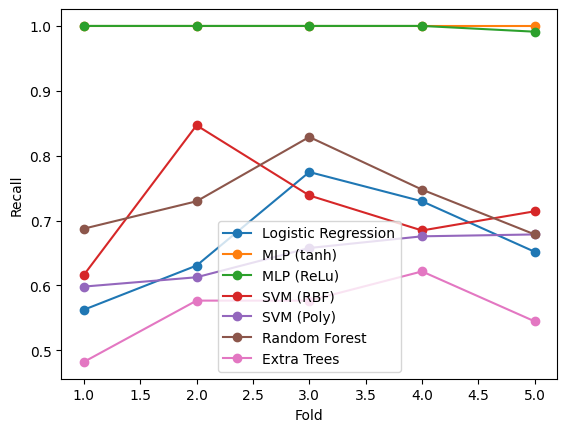

In [36]:

recalls = pd.DataFrame({
    "Logistic Regression": [0.5625, 0.6306, 0.7748, 0.7297, 0.6518],
    "MLP (tanh)": [1.0, 1.0, 1.0, 1.0, 1.0],
    "MLP (ReLu)": [1.0, 1.0, 1.0, 1.0, 0.9911],
    "SVM (RBF)": [0.6161, 0.8468, 0.7387, 0.6847, 0.7143],
    "SVM (Poly)": [0.5982, 0.6126, 0.6577, 0.6757, 0.6786],
    "Random Forest": [0.6875, 0.7297, 0.8288, 0.7477, 0.6786],
    "Extra Trees": [0.4821, 0.5766, 0.5766, 0.6216, 0.5446],
}, index = [1,2,3,4,5])

recalls.plot(marker='o', xlabel="Fold", ylabel="Recall")
print(recalls.mean().round(4))



Based on the recall scores the MLPs have the highest recall but they most likely arent useful because they predict basically everyone as having heart disease. The random forest has the highest recall next up with 0.73 which would be a good one to look into. 